# Defense Techniques

To protect our model from attacks, we will generate attacked data and train it on the attacked data!

# Imports

In [5]:
import torch.optim as optim
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
])

caltech101_dataset = datasets.Caltech101(root='../caltech_data', download=False, transform=transform)

test_loader = DataLoader(caltech101_dataset, batch_size=1, shuffle=True)

NUM_CLASSES = 101


def load_resnet34(weights_path, num_classes=NUM_CLASSES, device=device):

    model = models.resnet34(weights=None)
    
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    checkpoint = torch.load(weights_path, map_location=device)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    elif isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        model = checkpoint

    model = model.to(device)
    model.eval()
    return model


def load_mobilenet_v2(weights_path, num_classes=NUM_CLASSES, device=device):
    model = models.mobilenet_v2(weights=None)
    
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    
    checkpoint = torch.load(weights_path, map_location=device)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    elif isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        model = checkpoint

    model = model.to(device)
    model.eval()
    return model

Using device: cuda


In [7]:
resnet34_path = "../Phase1/resnet34_caltech101.pth"
mobilenet_path = "../Phase1/mobilenetv2_caltech101.pth"


resnet34_model = load_resnet34(resnet34_path)
print("ResNet-34 successfully loaded")

mobilenet_model = load_mobilenet_v2(mobilenet_path)
print("MobileNetV2 successfully loaded")

ResNet-34 successfully loaded
MobileNetV2 successfully loaded


In [8]:
def fgsm_attack(image, epsilon, data_grad):
    # Get the direction of the gradient (either +1 or -1 for every pixel)
    sign_data_grad = data_grad.sign()
    
    # Multiply by epsilon (attack strength) and add to the original image
    # Adds "noise" to the image
    perturbed_image = image + epsilon * sign_data_grad
    
    return perturbed_image

# Training on attacked data

In [9]:
def adversarial_train_epoch(model, device, train_loader, optimizer, epsilon):
    """
    Trains the model on a mix of clean and adversarial examples.
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        # ---------------------------------------------------------
        # 1. Generate Adversarial Examples
        # ---------------------------------------------------------
        # We need gradients for the input data to create the attack
        data.requires_grad = True
        
        # Forward pass on clean data
        output_clean = model(data)
        loss_clean = F.cross_entropy(output_clean, target)
        
        # Calculate gradients for FGSM
        model.zero_grad()
        loss_clean.backward(retain_graph=True) 
        data_grad = data.grad.data
        
        # Apply FGSM to create the attacked batch
        # (Using the fgsm_attack function we defined in Phase 2)
        adv_data = fgsm_attack(data, epsilon, data_grad)
        
        # ---------------------------------------------------------
        # 2. Train on Both Clean and Attacked Images
        # ---------------------------------------------------------
        optimizer.zero_grad()
        
        # We already have the output for clean data, now get output for adv data
        output_adv = model(adv_data)
        loss_adv = F.cross_entropy(output_adv, target)
        
        # Combine the losses: teach it to be accurate on both!
        combined_loss = 0.5 * loss_clean + 0.5 * loss_adv
        
        # Backward pass & optimize
        combined_loss.backward()
        optimizer.step()

        # Track metrics (we'll track accuracy on the adversarial examples)
        total_loss += combined_loss.item()
        pred_adv = output_adv.argmax(dim=1, keepdim=True)
        correct += pred_adv.eq(target.view_as(pred_adv)).sum().item()
        total += target.size(0)

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{len(train_loader)} | Combined Loss: {combined_loss.item():.4f} | Adv Batch Accuracy: {100. * correct / total:.2f}%")
            
    return model

In [10]:
import copy

print("--- Initiating Countermeasure Protocol: Adversarial Training ---")

# 1. Clone the original vulnerable model to create our hardened version
hardened_resnet = copy.deepcopy(resnet34_model).to(device)

# 2. Setup Optimizer (Lower learning rate since it is already fine-tuned)
optimizer = optim.Adam(hardened_resnet.parameters(), lr=0.0001)

# 3. Define the training epsilon (the strength of attacks it will learn to defend against)
training_epsilon = 0.15 

# Note: You must define 'train_loader' using your Phase 1 training set. 
# For demonstration, if you only have test_loader loaded right now, 
# you can test the loop using test_loader (though strictly speaking, you shouldn't train on test data).
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 4. Run Adversarial Training (1 Epoch for demonstration)
print(f"Training Hardened Model against Epsilon {training_epsilon}...")
hardened_resnet = adversarial_train_epoch(hardened_resnet, device, test_loader, optimizer, training_epsilon)
print("Model Hardening Complete.")

--- Initiating Countermeasure Protocol: Adversarial Training ---
Training Hardened Model against Epsilon 0.15...
Batch 0/8677 | Combined Loss: 4.3194 | Adv Batch Accuracy: 0.00%
Batch 20/8677 | Combined Loss: 5.4595 | Adv Batch Accuracy: 4.76%
Batch 40/8677 | Combined Loss: 5.4226 | Adv Batch Accuracy: 4.88%
Batch 60/8677 | Combined Loss: 4.3983 | Adv Batch Accuracy: 4.92%
Batch 80/8677 | Combined Loss: 6.1341 | Adv Batch Accuracy: 7.41%
Batch 100/8677 | Combined Loss: 6.2030 | Adv Batch Accuracy: 8.91%
Batch 120/8677 | Combined Loss: 6.6216 | Adv Batch Accuracy: 9.92%
Batch 140/8677 | Combined Loss: 6.0994 | Adv Batch Accuracy: 12.77%
Batch 160/8677 | Combined Loss: 4.9127 | Adv Batch Accuracy: 14.29%
Batch 180/8677 | Combined Loss: 1.5020 | Adv Batch Accuracy: 15.47%
Batch 200/8677 | Combined Loss: 5.3952 | Adv Batch Accuracy: 17.41%
Batch 220/8677 | Combined Loss: 0.6727 | Adv Batch Accuracy: 19.91%
Batch 240/8677 | Combined Loss: 0.4545 | Adv Batch Accuracy: 19.92%
Batch 260/8677 |

In [11]:
def test_fgsm_fast(model, device, test_loader, epsilon, max_samples=200):
    correct = 0
    adv_examples = []
    processed_count = 0

    for data, target in test_loader:
        # Stop once we hit our sample limit to save time
        if processed_count >= max_samples:
            break
            
        data, target = data.to(device), target.to(device)
        data.requires_grad = True

        output = model(data)
        init_pred = output.max(1, keepdim=True)[1]

        # Only evaluate on images the model initially got right
        if init_pred.item() != target.item():
            continue

        loss = F.cross_entropy(output, target)
        model.zero_grad()
        loss.backward()
        data_grad = data.grad.data

        # Apply the FGSM attack
        perturbed_data = fgsm_attack(data, epsilon, data_grad)
        output = model(perturbed_data)
        final_pred = output.max(1, keepdim=True)[1]

        # Check if the attack was successful
        if final_pred.item() == target.item():
            correct += 1
            if (epsilon == 0) and (len(adv_examples) < 5):
                adv_examples.append((init_pred.item(), final_pred.item(), perturbed_data.squeeze().detach().cpu()))
        else:
            if len(adv_examples) < 5:
                adv_examples.append((init_pred.item(), final_pred.item(), perturbed_data.squeeze().detach().cpu()))

        processed_count += 1 

    final_acc = correct / float(processed_count)
    # print(f"Epsilon: {epsilon:.2f}\tAccuracy = {correct}/{processed_count} ({final_acc * 100:.2f}%)")
    return final_acc, adv_examples

In [12]:
def evaluate_showdown(model, device, test_loader, epsilon):
    """Evaluates a model on clean data and attacked data."""
    # We can reuse our test_fgsm_fast function from Phase 2
    # First, test on Clean data (Epsilon = 0)
    print("Evaluating on Clean Test Set...")
    clean_acc, _ = test_fgsm_fast(model, device, test_loader, epsilon=0.0, max_samples=100)
    
    # Second, test on Attacked data
    print(f"Evaluating on Attacked Test Set (Epsilon = {epsilon})...")
    adv_acc, _ = test_fgsm_fast(model, device, test_loader, epsilon=epsilon, max_samples=100)
    
    return clean_acc, adv_acc

print("\n================ THE SHOWDOWN ================")
eval_epsilon = 0.15

print("\n[ ORIGINAL MODEL (Vulnerable) ]")
orig_clean_acc, orig_adv_acc = evaluate_showdown(resnet34_model, device, test_loader, eval_epsilon)

print("\n[ HARDENED MODEL (Adversarially Trained) ]")
hard_clean_acc, hard_adv_acc = evaluate_showdown(hardened_resnet, device, test_loader, eval_epsilon)

print("\n================ FINAL RESULTS ===============")
print(f"Model          | Clean Accuracy | Attacked Accuracy (Eps={eval_epsilon})")
print(f"--------------------------------------------------------------")
print(f"Original       | {orig_clean_acc*100:14.2f}% | {orig_adv_acc*100:17.2f}%")
print(f"Hardened       | {hard_clean_acc*100:14.2f}% | {hard_adv_acc*100:17.2f}%")


================ THE SHOWDOWN ================

[ ORIGINAL MODEL (Vulnerable) ]
Evaluating on Clean Test Set...
Evaluating on Attacked Test Set (Epsilon = 0.15)...

[ HARDENED MODEL (Adversarially Trained) ]
Evaluating on Clean Test Set...
Evaluating on Attacked Test Set (Epsilon = 0.15)...

================ FINAL RESULTS ===============
Model          | Clean Accuracy | Attacked Accuracy (Eps=0.15)
--------------------------------------------------------------
Original       |         100.00% |              8.00%
Hardened       |         100.00% |             81.00%


Now lets do saliency and gradcam

In [13]:
def generate_saliency_map(model, image, target_class=None):
    # Puts the model in testing mode
    model.eval()
    
    # Clone and detach the image to create a clean leaf tensor, 
    # then explicitly require gradients for it.
    img_tensor = image.clone().detach().requires_grad_(True)
    
    # Forward pass
    output = model(img_tensor)
    
    # If no target class is specified, use the model's top prediction
    if target_class is None:
        target_class = output.argmax(dim=1).item()
        
    # Get the specific score for the target class
    score = output[0, target_class]
    
    # Clear previous gradients and run backward pass
    model.zero_grad()
    score.backward()
    
    # Extract the gradients of the input image
    gradients = img_tensor.grad.data.abs().squeeze()
    
    # Take the maximum across the 3 color channels to get a single 2D map
    saliency, _ = torch.max(gradients, dim=0)
    
    # Normalize the map between 0 and 1 for clean visualization
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())
    
    return saliency.cpu().numpy()

def visualize_saliency(original_image_tensor, saliency_map, title="Saliency Map"):
    
    # Convert image tensor back to numpy for matplotlib
    # Assuming the tensor is (1, 3, 224, 224) and values are [0, 1]
    img = original_image_tensor.squeeze().detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0)) # Change to (H, W, C)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')
    
    # Plot the saliency map using a heatmap colormap (e.g., 'hot' or 'jet')
    im = ax[1].imshow(saliency_map, cmap='hot')
    ax[1].set_title(title)
    ax[1].axis('off')
    
    plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
    plt.show()

In [14]:
import torch.nn.functional as F
from matplotlib import colormaps

class GradCAM:
    def __init__(self, model, target_layer):
        """
        Attaches hooks to the target layer to intercept activations and gradients.
        """
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks to intercept the data flowing through the target layer
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_image, target_class=None):
        """
        Generates the Grad-CAM heatmap for a given image and target class.
        """
        self.model.eval()
        input_image = input_image.clone().detach().requires_grad_(True)
        
        # Forward pass
        output = self.model(input_image)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
            
        # Backward pass
        self.model.zero_grad()
        score = output[0, target_class]
        score.backward()
        
        # Get the gradients and activations we captured
        gradients = self.gradients
        activations = self.activations
        
        # Global Average Pooling on the gradients to get the "weights"
        # We average across the spatial dimensions (height and width)
        weights = torch.mean(gradients, dim=[2, 3], keepdim=True)
        
        # Multiply the feature map (activations) by the importance weights
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        
        # Apply ReLU to only keep features that have a positive influence
        cam = F.relu(cam)
        
        # Resize the small feature map back to the original image size (224x224)
        cam = F.interpolate(cam, size=input_image.shape[2:], mode='bilinear', align_corners=False)
        
        # Normalize the map between 0 and 1
        cam = cam.squeeze()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        return cam.cpu().numpy()


In [15]:
def visualize_gradcam(image_tensor, cam, title="Grad-CAM"):
    """
    Overlays the Grad-CAM heatmap on the original image.
    """
    # Convert original image to numpy [H, W, C]
    img = image_tensor.squeeze().detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    
    # Get the colormap and create the heatmap
    cmap = colormaps.get_cmap('jet')
    heatmap = cmap(cam)[..., :3] # Keep only RGB channels from cmap
    
    # Blend the original image and the heatmap
    overlay = 0.5 * heatmap + 0.5 * img
    overlay = np.clip(overlay, 0, 1) # Ensure valid pixel range
    
    # Plotting
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')
    
    ax[1].imshow(cam, cmap='jet')
    ax[1].set_title("Raw Heatmap")
    ax[1].axis('off')
    
    ax[2].imshow(overlay)
    ax[2].set_title(title)
    ax[2].axis('off')
    
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15..1.1147059].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15..1.1147059].


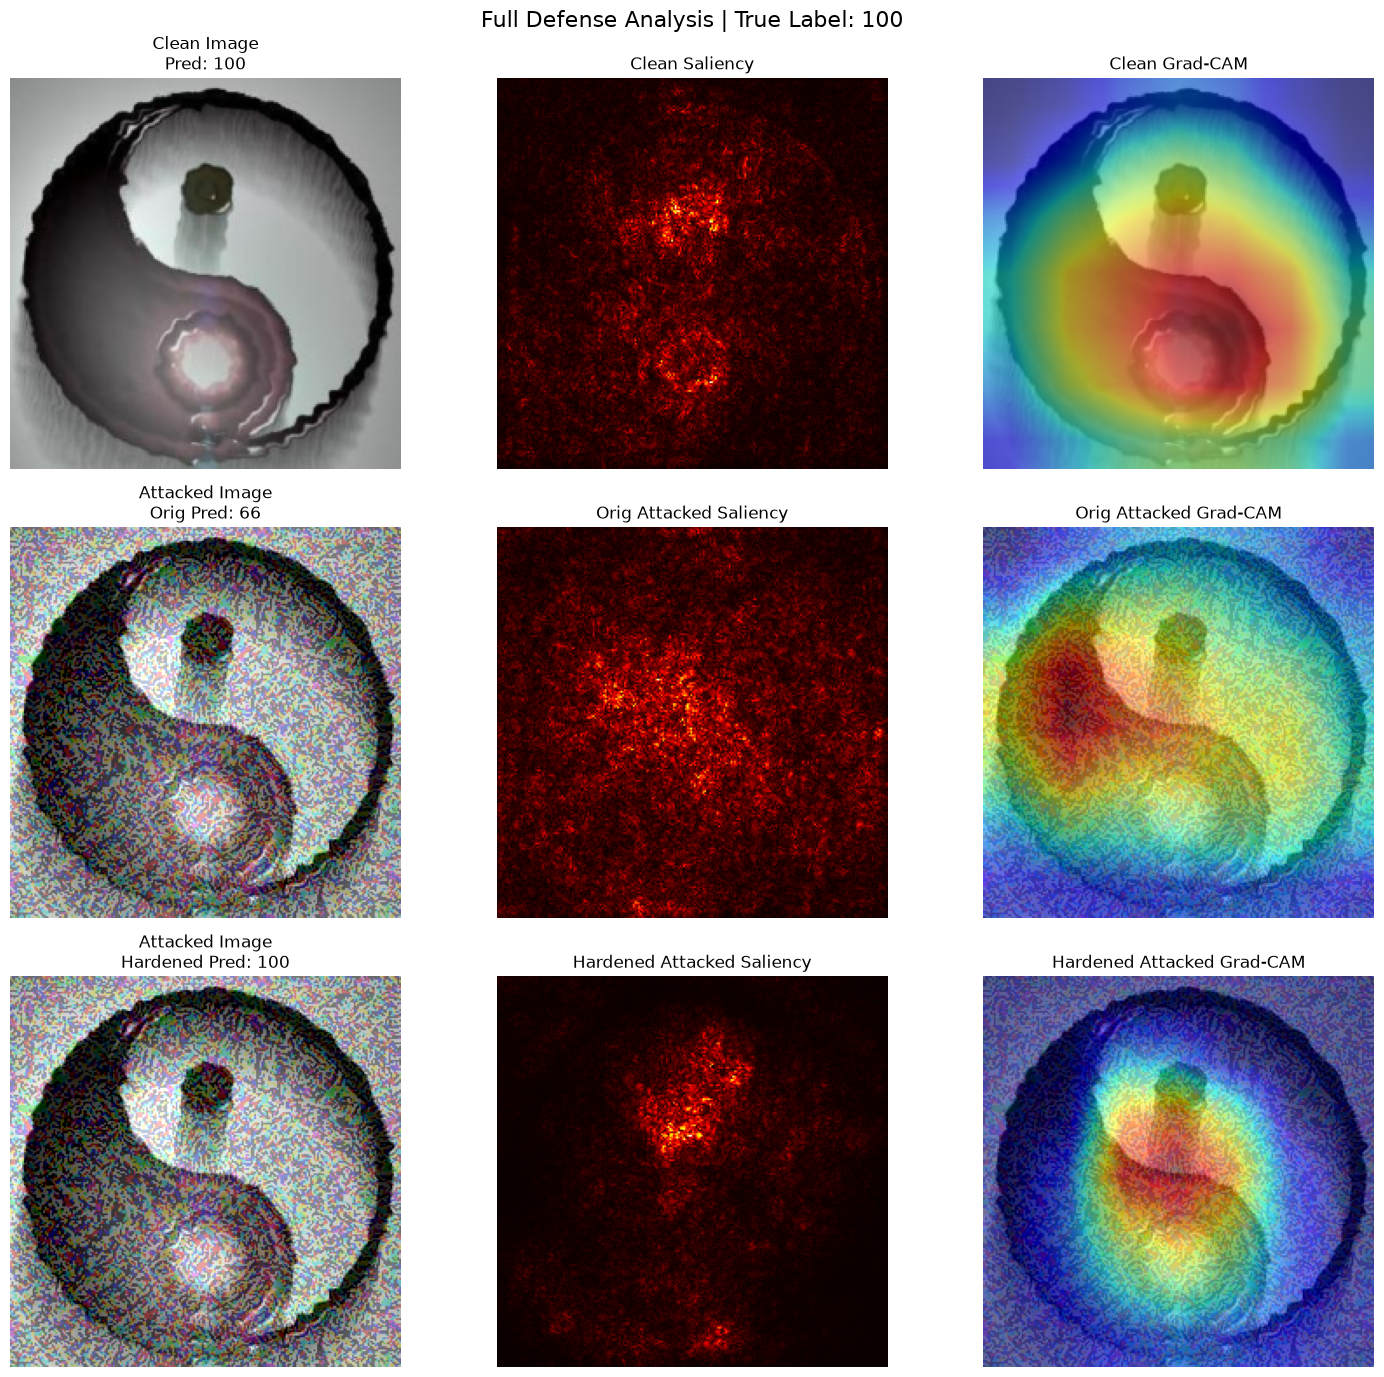

In [20]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps

def ultimate_defense_dashboard(orig_model, hard_model, image, target, epsilon, orig_layer, hard_layer):
    """
    Creates a 3x3 grid comparing Clean Baseline, Vulnerable Attack, and Hardened Defense.
    """
    orig_model.eval()
    hard_model.eval()
    
    # ---------------------------------------------------------
    # 1. Clean Baseline (Original Model)
    # ---------------------------------------------------------
    img_clean = image.clone().detach().requires_grad_(True)
    out_clean = orig_model(img_clean)
    pred_clean = out_clean.argmax(dim=1).item()
    
    sal_clean = generate_saliency_map(orig_model, img_clean, pred_clean)
    cam_clean = GradCAM(orig_model, orig_layer).generate_cam(img_clean, pred_clean)
    
    # ---------------------------------------------------------
    # 2. Generate Attack
    # ---------------------------------------------------------
    orig_model.zero_grad()
    loss = F.cross_entropy(out_clean, target)
    loss.backward()
    data_grad = img_clean.grad.data
    adv_image = fgsm_attack(image, epsilon, data_grad)
    
    # ---------------------------------------------------------
    # 3. Attacked - Original Model
    # ---------------------------------------------------------
    out_orig_adv = orig_model(adv_image)
    pred_orig_adv = out_orig_adv.argmax(dim=1).item()
    
    sal_orig = generate_saliency_map(orig_model, adv_image, pred_orig_adv)
    cam_orig = GradCAM(orig_model, orig_layer).generate_cam(adv_image, pred_orig_adv)
    
    # ---------------------------------------------------------
    # 4. Attacked - Hardened Model
    # ---------------------------------------------------------
    out_hard_adv = hard_model(adv_image)
    pred_hard_adv = out_hard_adv.argmax(dim=1).item()
    
    sal_hard = generate_saliency_map(hard_model, adv_image, pred_hard_adv)
    cam_hard = GradCAM(hard_model, hard_layer).generate_cam(adv_image, pred_hard_adv)

    # ---------------------------------------------------------
    # 5. Plotting
    # ---------------------------------------------------------
    def format_img(t):
        return np.transpose(t.squeeze().detach().cpu().numpy(), (1, 2, 0))
    
    def get_overlay(img_t, cam):
        i = format_img(img_t)
        heatmap = colormaps.get_cmap('jet')(cam)[..., :3]
        return np.clip(0.5 * heatmap + 0.5 * i, 0, 1)

    fig, axes = plt.subplots(3, 3, figsize=(15, 14))
    fig.suptitle(f"Full Defense Analysis | True Label: {target.item()}", fontsize=16)

    # Row 1: Clean Baseline
    axes[0, 0].imshow(format_img(image))
    axes[0, 0].set_title(f"Clean Image\nPred: {pred_clean}")
    axes[0, 1].imshow(sal_clean, cmap='hot')
    axes[0, 1].set_title("Clean Saliency")
    axes[0, 2].imshow(get_overlay(image, cam_clean))
    axes[0, 2].set_title("Clean Grad-CAM")

    # Row 2: Original Model Attacked
    axes[1, 0].imshow(format_img(adv_image))
    axes[1, 0].set_title(f"Attacked Image\nOrig Pred: {pred_orig_adv}")
    axes[1, 1].imshow(sal_orig, cmap='hot')
    axes[1, 1].set_title("Orig Attacked Saliency")
    axes[1, 2].imshow(get_overlay(adv_image, cam_orig))
    axes[1, 2].set_title("Orig Attacked Grad-CAM")

    # Row 3: Hardened Model Attacked
    axes[2, 0].imshow(format_img(adv_image))
    axes[2, 0].set_title(f"Attacked Image\nHardened Pred: {pred_hard_adv}")
    axes[2, 1].imshow(sal_hard, cmap='hot')
    axes[2, 1].set_title("Hardened Attacked Saliency")
    axes[2, 2].imshow(get_overlay(adv_image, cam_hard))
    axes[2, 2].set_title("Hardened Attacked Grad-CAM")

    for ax in axes.flatten():
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Execution
ultimate_defense_dashboard(resnet34_model, hardened_resnet, image, target, epsilon=0.15, orig_layer=layer_orig, hard_layer=layer_hard)